In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [132]:
df=sns.load_dataset('iris')

In [133]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [134]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv('pima-indians-diabetes.csv', names=columns)



In [135]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [136]:
duplicates = df.duplicated()
print("Số dòng trùng lặp:", duplicates.sum())

df_cleaned = df.drop_duplicates()
print("Số dòng sau khi loại bỏ trùng lặp:", df_cleaned.shape)

Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: (768, 9)


In [137]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (40, 200),
    'BloodPressure': (20, 140),
    'SkinThickness': (5, 99),
    'Insulin': (15, 846),
    'BMI': (15, 60),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (10, 100)
}

In [138]:
def detect_physiological_errors(df, physiological_ranges):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('df must be a pandas DataFrame')
    if not isinstance(physiological_ranges, dict):
        raise TypeError('physiological_ranges must be a dict')
    errors = {}
    for col, valid_range in physiological_ranges.items():
        if col not in df.columns:
            continue
        if not (isinstance(valid_range, (tuple, list)) and len(valid_range) == 2):
            raise ValueError(f'Range for {col} must be tuple/list (min, max)')
        min_val, max_val = valid_range
        col_values = df[col]
        invalid_mask = col_values.notna() & ((col_values < min_val) | (col_values > max_val))
        invalid_values = col_values[invalid_mask]
        if not invalid_values.empty:
            errors[col] = {
                'count': int(invalid_values.shape[0]),
                'min_actual': float(col_values.min()) if pd.notna(col_values.min()) else None,
                'max_actual': float(col_values.max()) if pd.notna(col_values.max()) else None,
                'problem_values': sorted(set(invalid_values.tolist()))
            }
    return errors

In [139]:
errors = detect_physiological_errors(df, physiological_ranges)
print("=== Dữ liệu lỗi phát hiện ===")
for col, info in errors.items():
        print(f"{col}: {info['count']} giá trị lỗi")
        print(f" -Range thực tế: {info['min_actual']} - {info['max_actual']}")
        print(f" -Giá trị có vấn đề: {info['problem_values']}")

=== Dữ liệu lỗi phát hiện ===
Glucose: 5 giá trị lỗi
 -Range thực tế: 0.0 - 199.0
 -Giá trị có vấn đề: [0]
BloodPressure: 35 giá trị lỗi
 -Range thực tế: 0.0 - 122.0
 -Giá trị có vấn đề: [0]
SkinThickness: 227 giá trị lỗi
 -Range thực tế: 0.0 - 99.0
 -Giá trị có vấn đề: [0]
Insulin: 375 giá trị lỗi
 -Range thực tế: 0.0 - 846.0
 -Giá trị có vấn đề: [0, 14]
BMI: 12 giá trị lỗi
 -Range thực tế: 0.0 - 67.1
 -Giá trị có vấn đề: [0.0, 67.1]


In [140]:

def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")
            median_val = df[col][df[col] > 0].median()
            df.loc[zero_mask, col] = median_val
            print(f" -> Đã thay thế bằng median: {median_val:.2f}")
    return df
df_final = handle_zero_values(df_cleaned)

Phát hiện 374 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


In [141]:
print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")
final_errors = detect_physiological_errors(df_final, physiological_ranges)
if not final_errors:
    print("Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 768 dòng
Tỷ lệ giữ lại: 100.0%
Vẫn còn dữ liệu lỗi:
 - Glucose: 5 lỗi
 - BloodPressure: 35 lỗi
 - Insulin: 1 lỗi
 - BMI: 12 lỗi


In [142]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


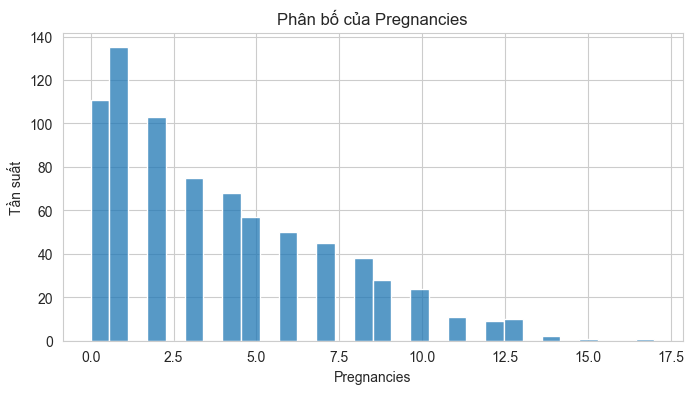

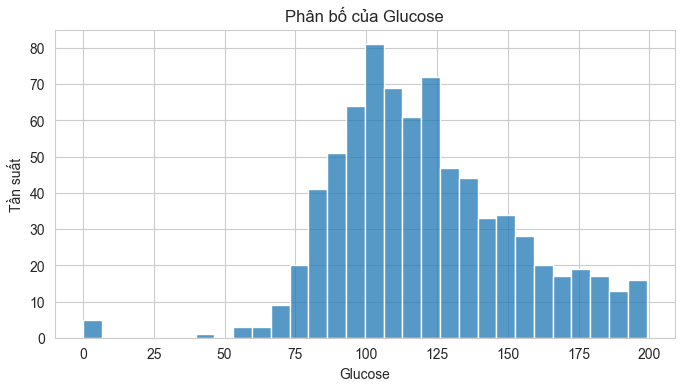

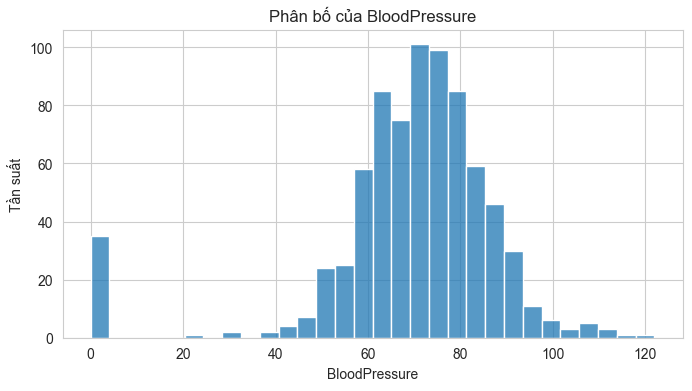

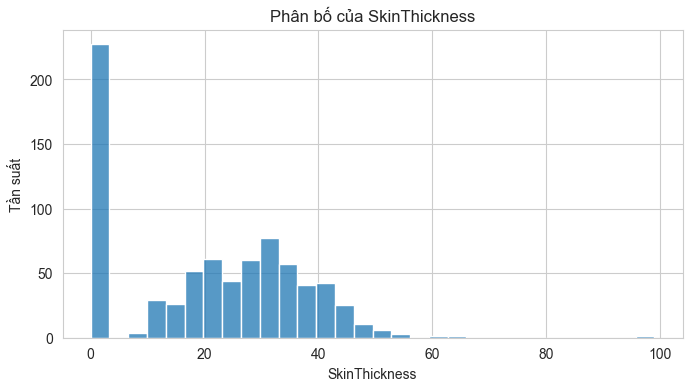

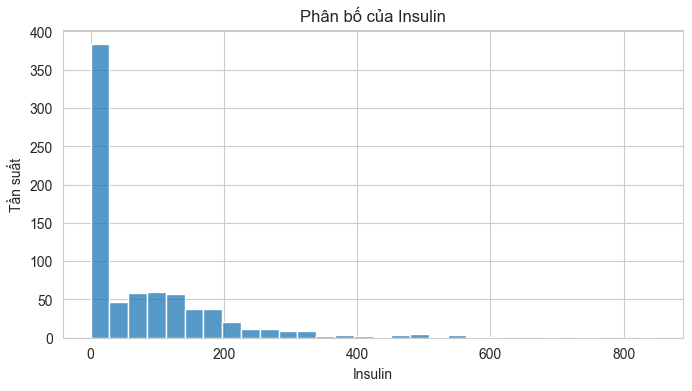

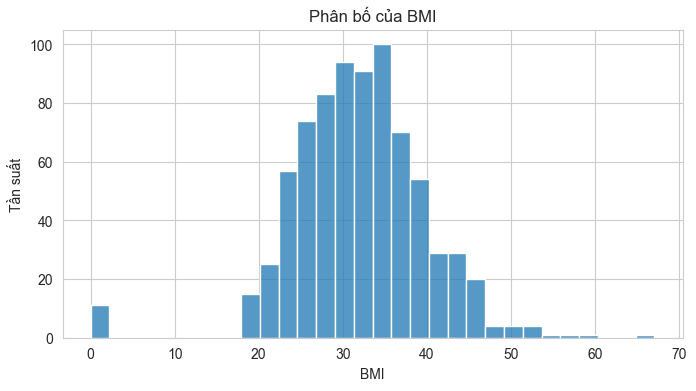

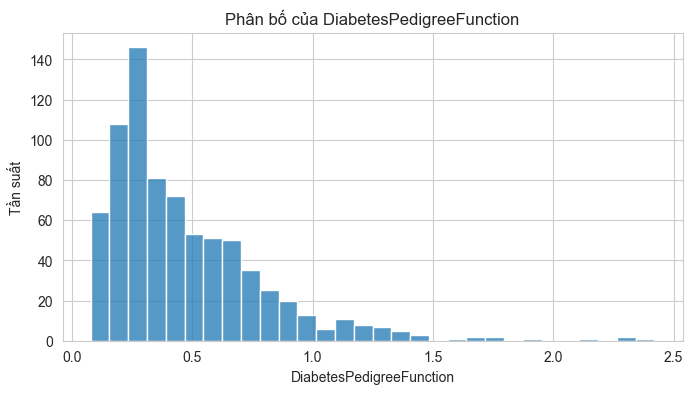

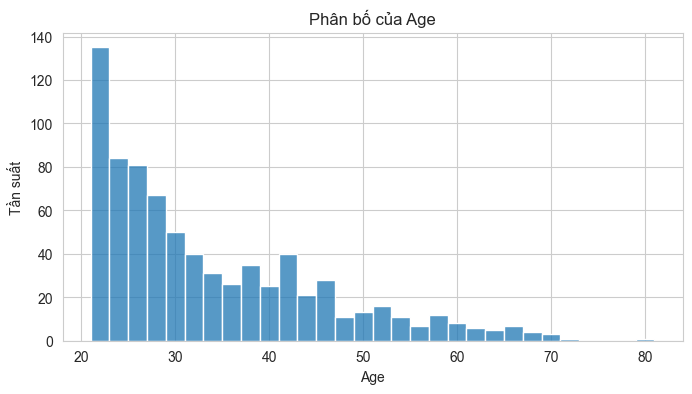

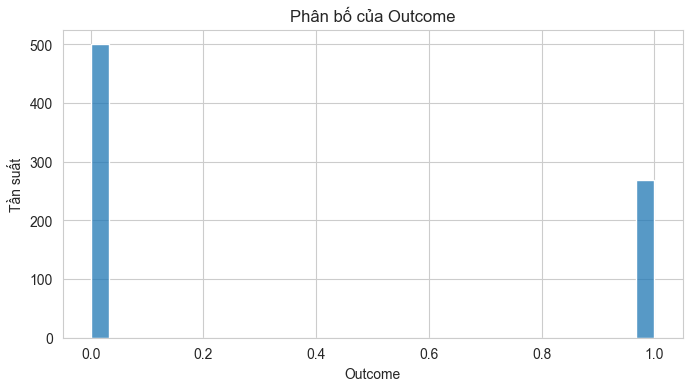

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns


for column in df.columns:
    plt.figure(figsize=(8, 4))
    if df[column].dtype in ['int64', 'float64']:
        sns.histplot(df[column], kde=False, bins=30)
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Tần suất')
    else:
        sns.countplot(x=df[column])
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Số lượng')
    plt.show()

=== PHÁT HIỆN OUTLIERS BẰNG IQR ===
Pregnancies: 4 outliers
  - Giới hạn dưới: -6.50, Giới hạn trên: 13.50
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(17)]...

Glucose: 5 outliers
  - Giới hạn dưới: 37.12, Giới hạn trên: 202.12
  - Giá trị outliers: [np.int64(0)]...

BloodPressure: 45 outliers
  - Giới hạn dưới: 35.00, Giới hạn trên: 107.00
  - Giá trị outliers: [np.int64(0), np.int64(24), np.int64(30), np.int64(108), np.int64(110), np.int64(114), np.int64(122)]...

SkinThickness: 87 outliers
  - Giới hạn dưới: 14.50, Giới hạn trên: 42.50
  - Giá trị outliers: [np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(43), np.int64(44), np.int64(45)]...

Insulin: 346 outliers
  - Giới hạn dưới: 112.88, Giới hạn trên: 135.88
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(29), np.int64(32), np.int64(36)]...

BMI: 19 outliers
  - Giới hạn dưới: 

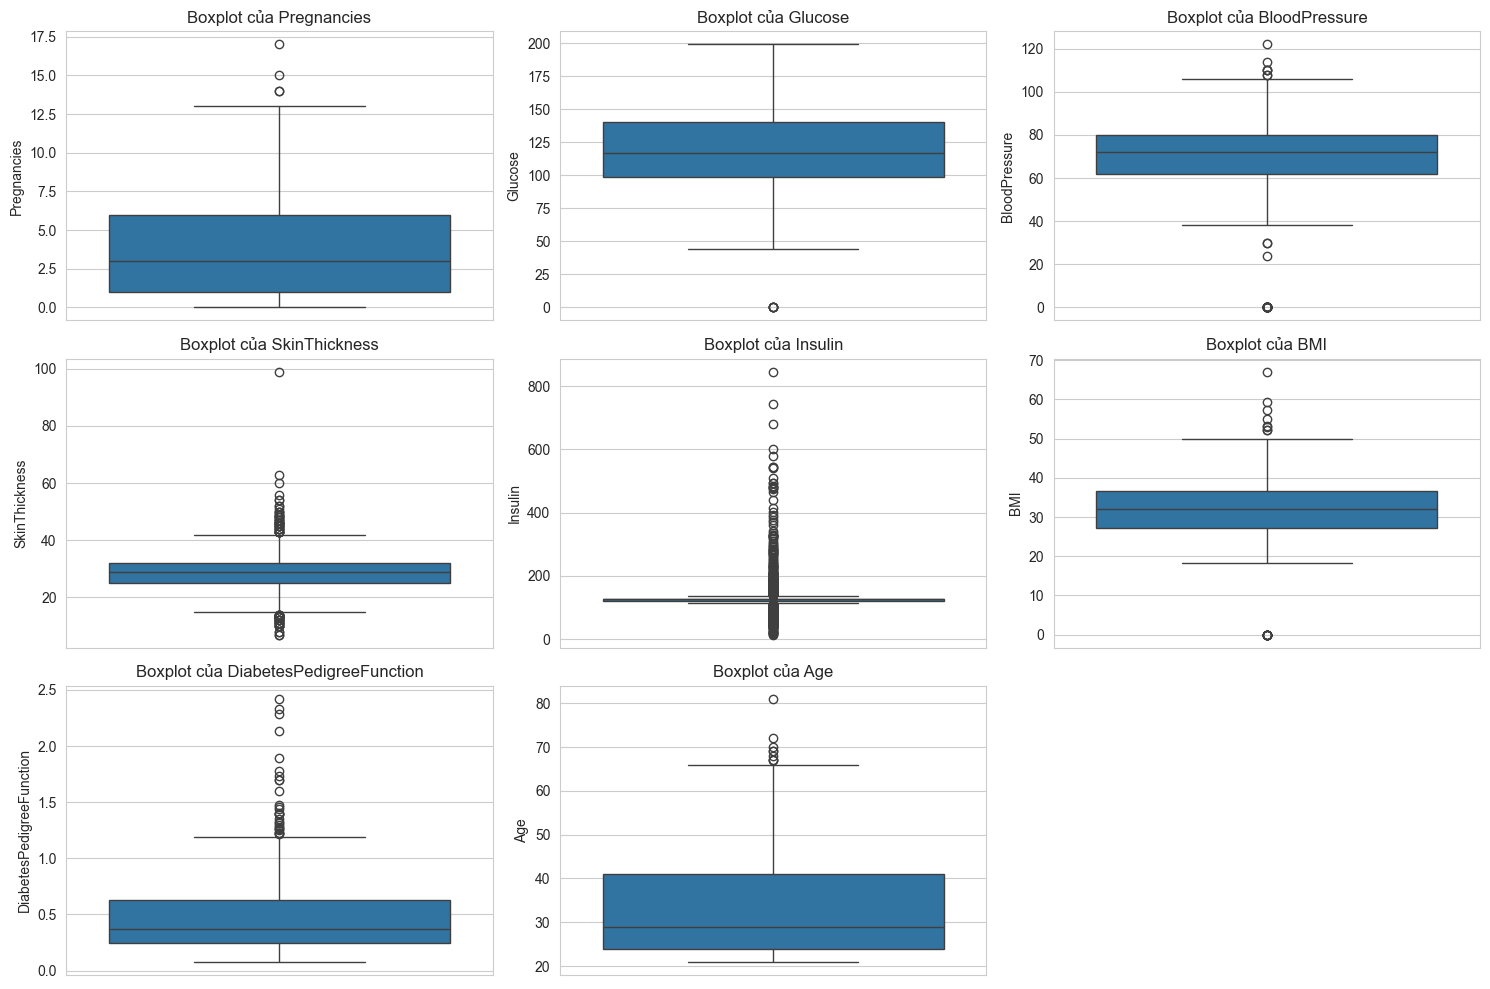

In [144]:
import numpy as np
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
print("=== PHÁT HIỆN OUTLIERS BẰNG IQR ===")
numeric_columns = df_final.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col != 'Outcome':  
        outliers, lower, upper = detect_outliers_iqr(df_final, col)
        print(f"{col}: {len(outliers)} outliers")
        if len(outliers) > 0:
            print(f"  - Giới hạn dưới: {lower:.2f}, Giới hạn trên: {upper:.2f}")
            print(f"  - Giá trị outliers: {sorted(outliers[col].unique())[:10]}...")  
        print()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    if col != 'Outcome':
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df_final[col])
        plt.title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

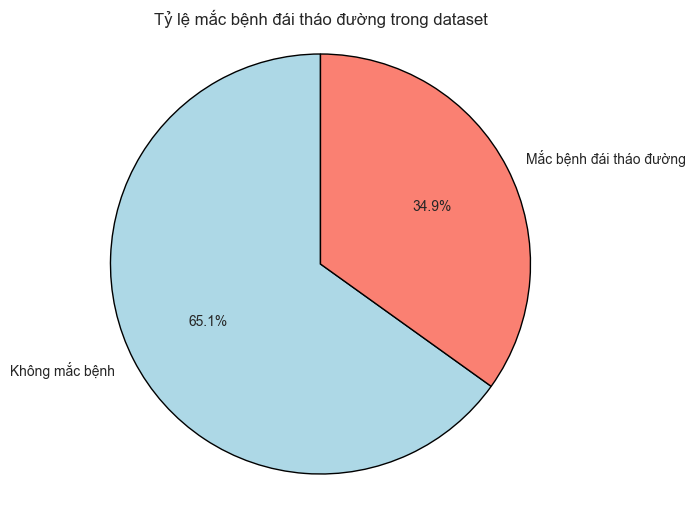

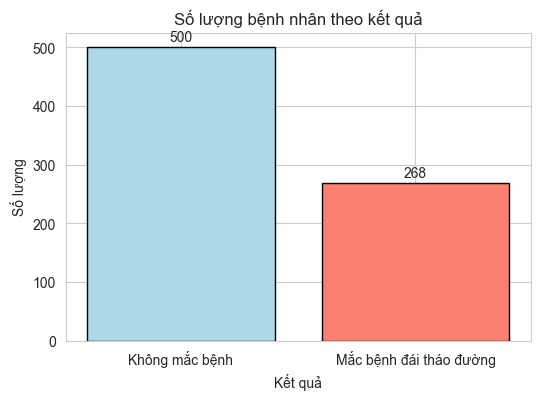

In [145]:
# Vẽ tỷ lệ mắc bệnh đái tháo đường
outcome_counts = df_final['Outcome'].value_counts()
labels = ['Không mắc bệnh', 'Mắc bệnh đái tháo đường']
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ mắc bệnh đái tháo đường trong dataset')
plt.axis('equal')  # Đảm bảo hình tròn
plt.show()

# Thêm bar chart để so sánh
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, outcome_counts.values, color=colors, edgecolor='black')
plt.title('Số lượng bệnh nhân theo kết quả')
plt.ylabel('Số lượng')
plt.xlabel('Kết quả')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', va='bottom')
plt.show()

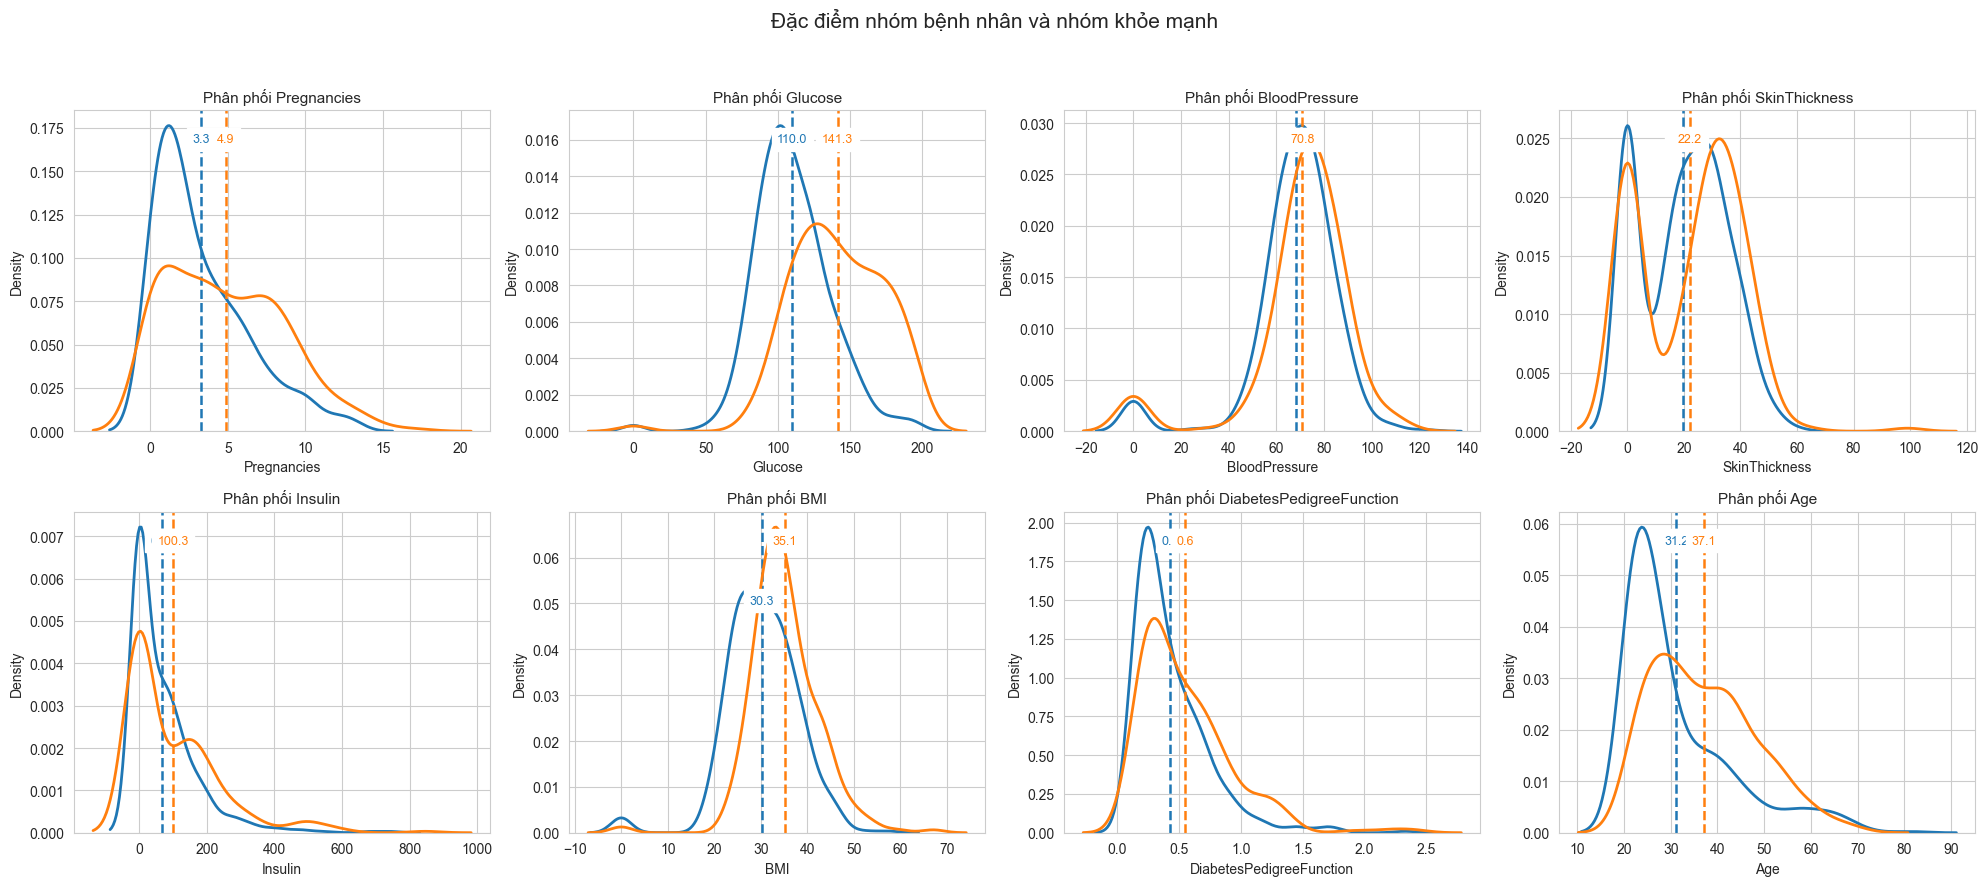

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Map label
df['Group'] = df['Outcome'].map({0: 'Không mắc', 1: 'Mắc'})

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e']

for i, col in enumerate(features):
    ax = axes[i]


    for group, color in zip(['Không mắc', 'Mắc'], colors):
        subset = df[df['Group'] == group]

        sns.kdeplot(data=subset,
                    x=col,
                    fill=False,     
                    linewidth=2,
                    color=color,
                    ax=ax)

        # Mean line
        mean_val = subset[col].mean()
        ax.axvline(mean_val,
                   color=color,
                   linestyle='--',
                   linewidth=1.8)

        # Text mean
        ax.text(mean_val,
                ax.get_ylim()[1]*0.9,
                f"{mean_val:.1f}",
                color=color,
                fontsize=9,
                ha='center',
                backgroundcolor='white')

    ax.set_title(f'Phân phối {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

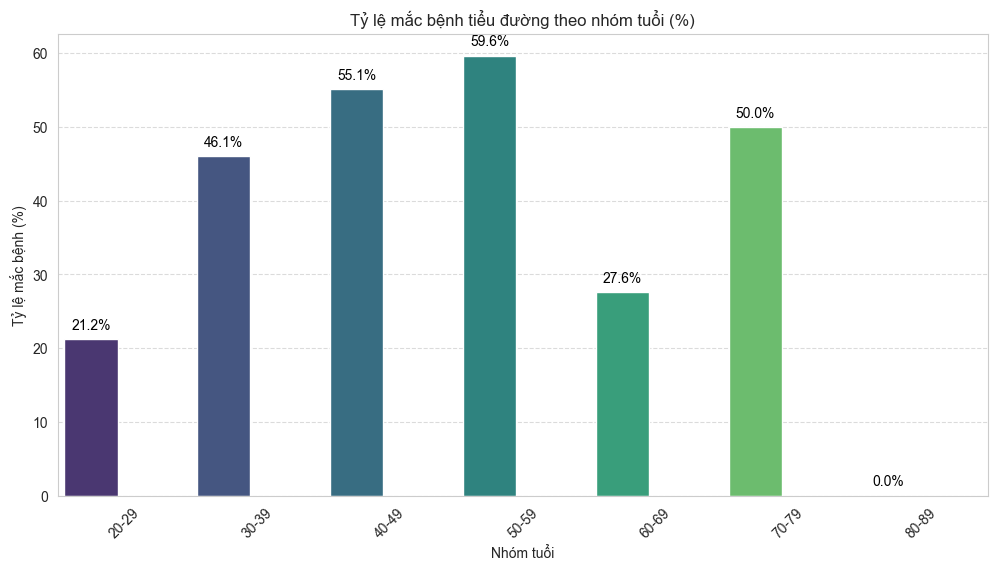

In [147]:
# Phân bố bệnh theo độ tuổi
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Tính tỷ lệ mắc bệnh theo nhóm tuổi
age_disease_rate = df.groupby('Age_Group')['Outcome'].mean().reset_index()
age_disease_rate['Outcome'] *= 100  # Chuyển thành phần trăm

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Outcome',
    hue='Age_Group',
    palette='viridis',
    legend=False
)

for bar in ax.patches:
    bar.set_width(0.4)

# chỉnh lại vị trí để không bị lệch
for bar in ax.patches:
    bar.set_x(bar.get_x() - 0.05)

plt.title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số % trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black',
                xytext=(0, 5), textcoords='offset points')
    
plt.show()

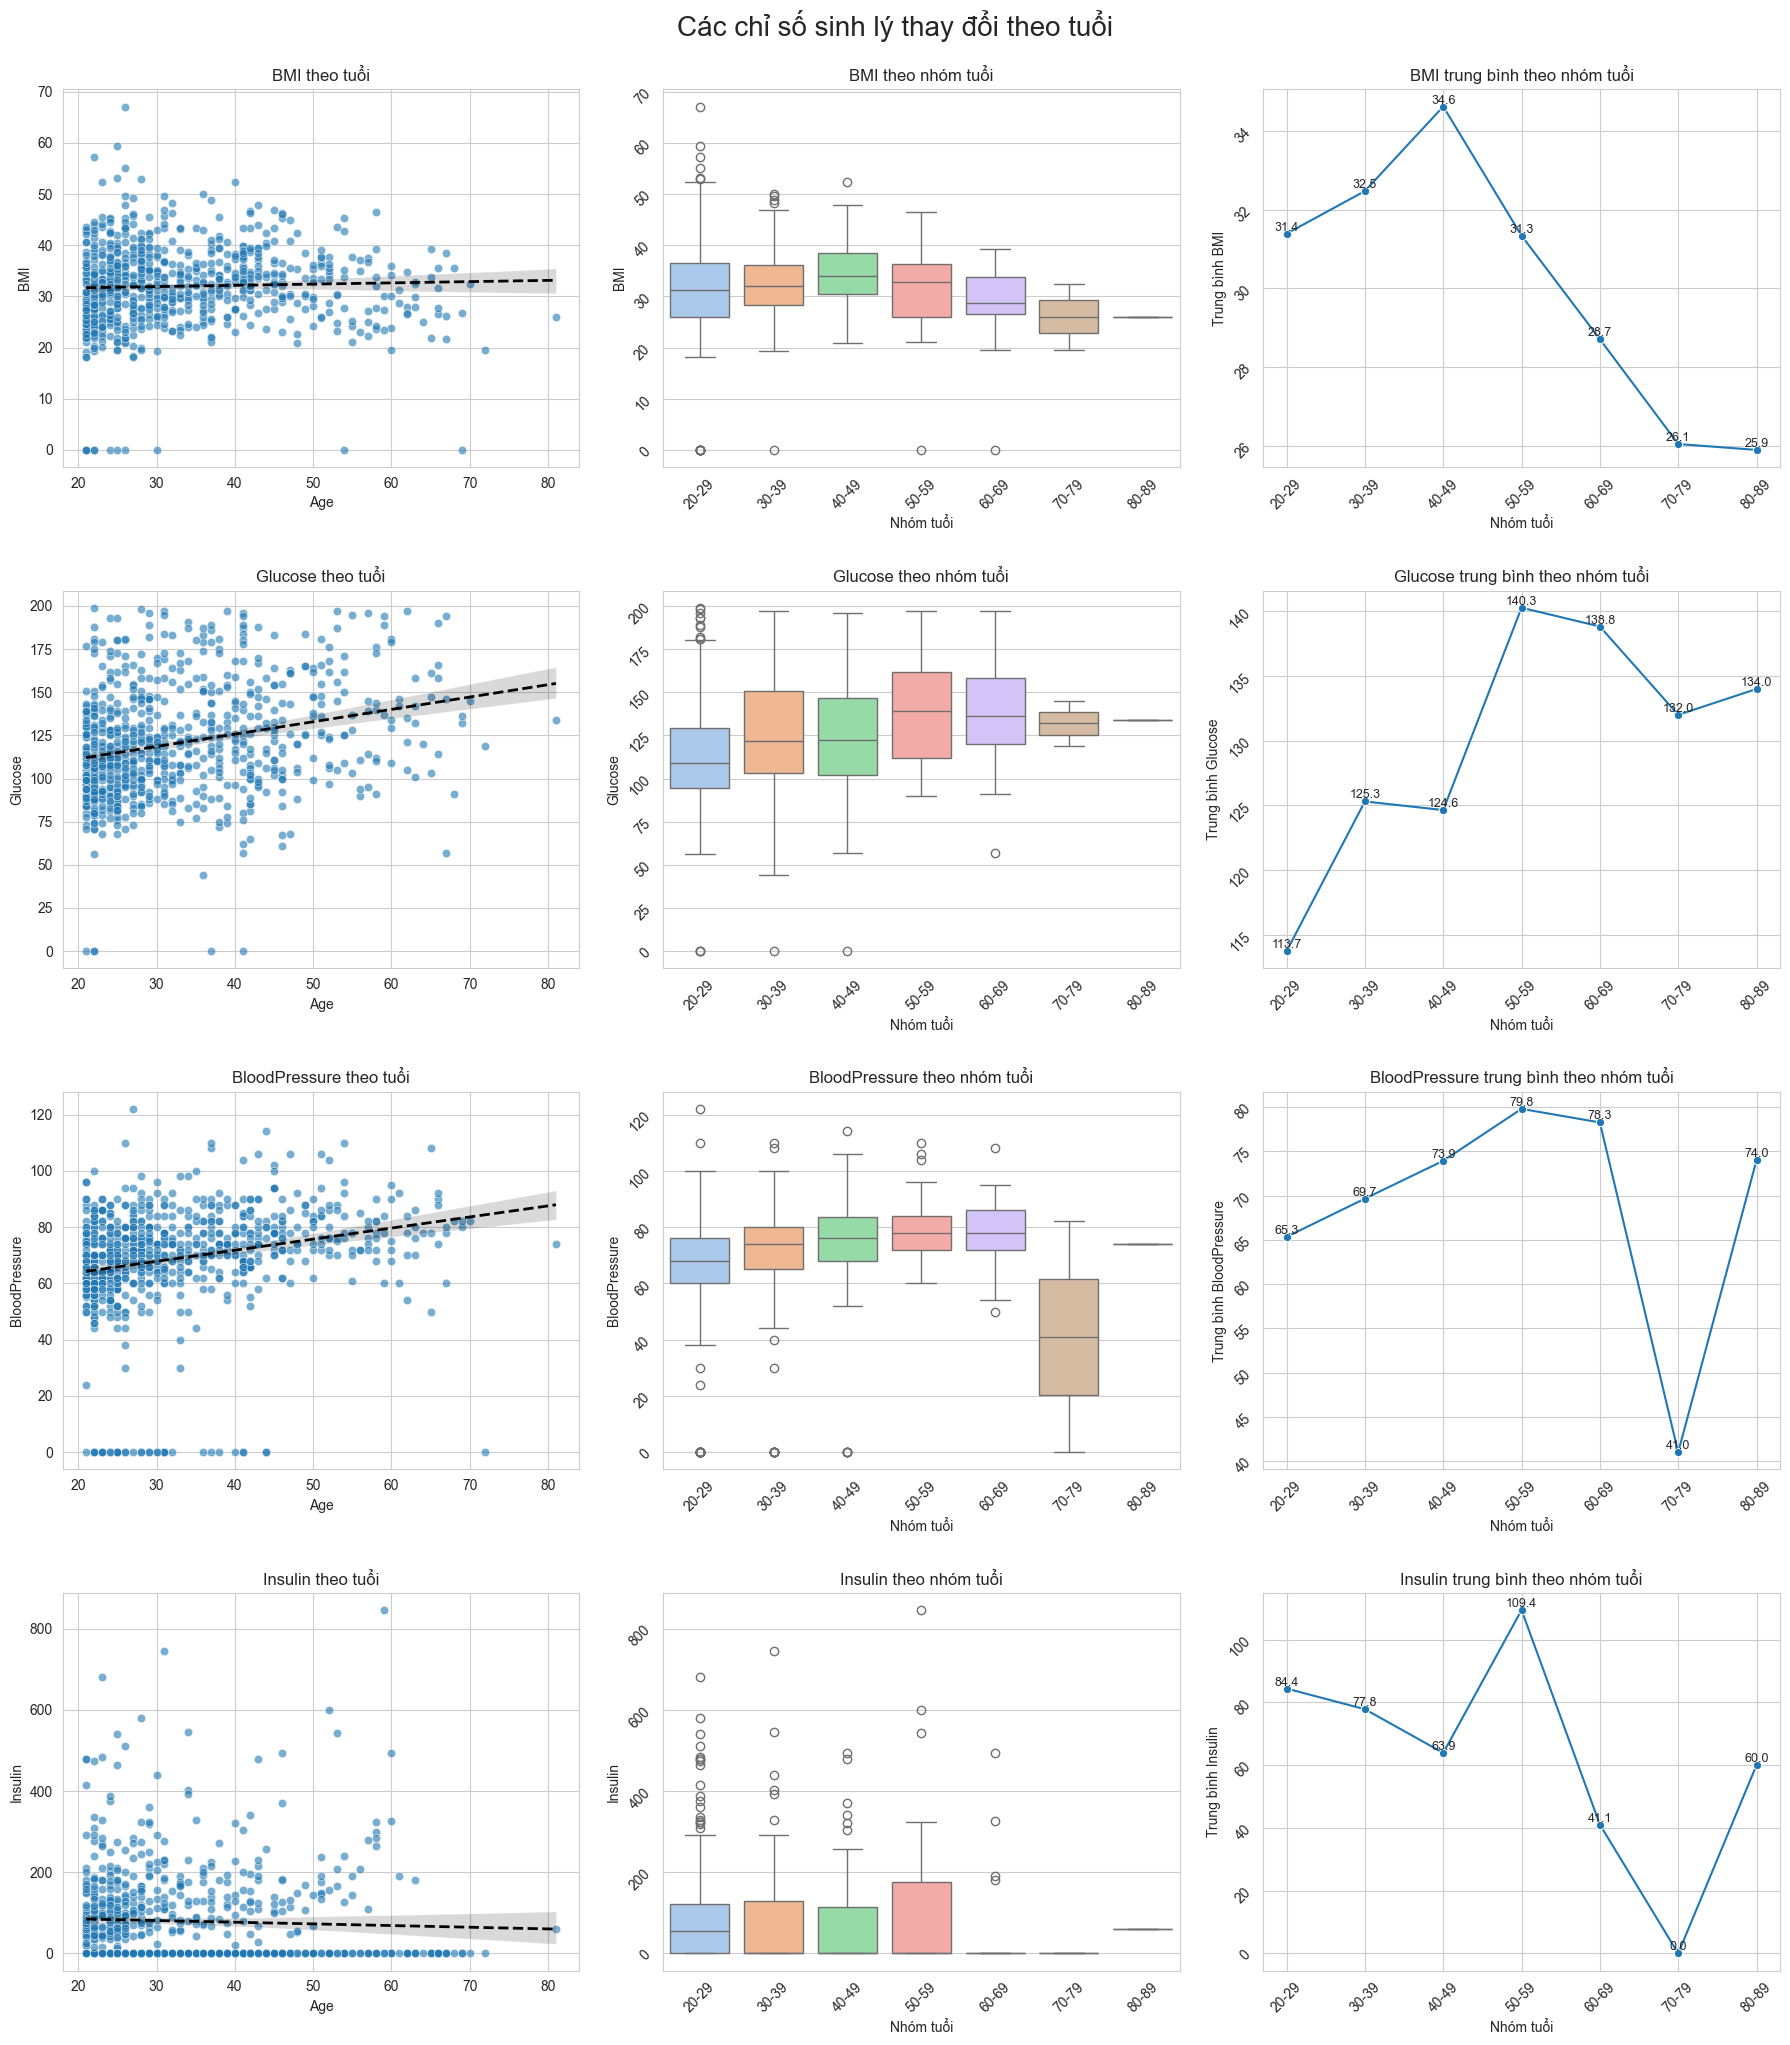

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

features = ['BMI', 'Glucose', 'BloodPressure', 'Insulin']

sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):
    # 1) Scatter + trendline (tất cả data)
    ax = axes[i*3 + 0]
    sns.scatterplot(data=df, x='Age', y=feat, color='#1f77b4', alpha=0.6, ax=ax)
    sns.regplot(data=df, x='Age', y=feat, scatter=False, ax=ax,
                line_kws={'color':'black','lw':2,'ls':'--'})
    ax.set_title(f'{feat} theo tuổi')
    ax.set_xlabel('Age')
    ax.set_ylabel(feat)

    # 2) Boxplot theo nhóm tuổi
    ax = axes[i*3 + 1]
    sns.boxplot(data=df, x='Age_Group', y=feat, ax=ax, palette='pastel')
    ax.set_title(f'{feat} theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(feat)
    ax.tick_params(rotation=45)

    # 3) Trung bình theo nhóm tuổi
    avg = df.groupby('Age_Group')[feat].mean().reset_index()
    ax = axes[i*3 + 2]
    sns.lineplot(data=avg, x='Age_Group', y=feat, marker='o', ax=ax, color='tab:blue')
    ax.set_title(f'{feat} trung bình theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(f'Trung bình {feat}')
    ax.tick_params(rotation=45)
    for x, y in zip(avg['Age_Group'], avg[feat]):
        ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(h_pad=2.5, w_pad=2)
plt.suptitle('Các chỉ số sinh lý thay đổi theo tuổi', fontsize=20, y=1.02)
plt.show()

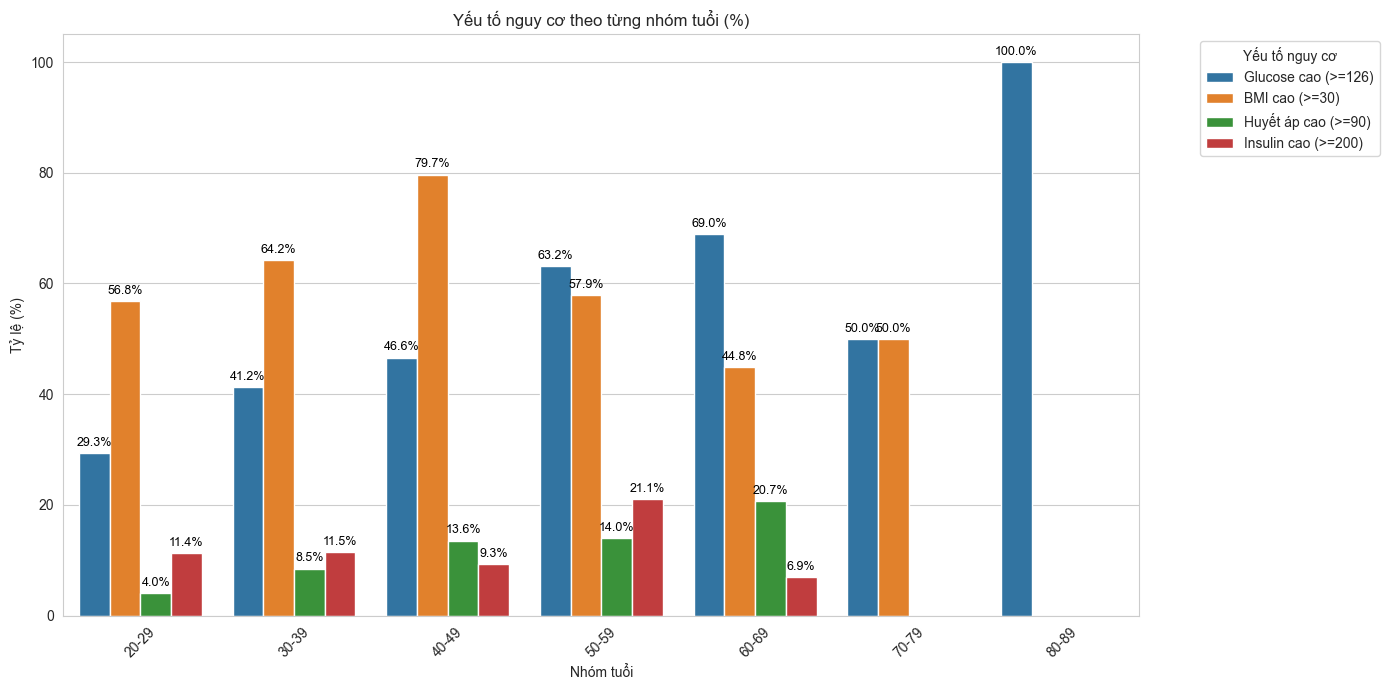

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Định nghĩa yếu tố nguy cơ
df['Risk_Glucose'] = (df['Glucose'] >= 126).astype(int)
df['Risk_BMI'] = (df['BMI'] >= 30).astype(int)
df['Risk_BP'] = (df['BloodPressure'] >= 90).astype(int)  # hoặc 80 tùy chọn
df['Risk_Insulin'] = (df['Insulin'] >= 200).astype(int)  # hội chẩn đặc trưng

# Tính phần trăm theo nhóm tuổi
risk_df = df.groupby('Age_Group')[['Risk_Glucose','Risk_BMI','Risk_BP','Risk_Insulin']].mean() * 100
risk_df = risk_df.reset_index()

# Chuyển long format cho seaborn
risk_melt = risk_df.melt(id_vars='Age_Group',
                         value_vars=['Risk_Glucose','Risk_BMI','Risk_BP','Risk_Insulin'],
                         var_name='Risk_Factor',
                         value_name='Percent')

# Nhãn đẹp hơn
risk_melt['Risk_Factor'] = risk_melt['Risk_Factor'].map({
    'Risk_Glucose': 'Glucose cao (>=126)',
    'Risk_BMI': 'BMI cao (>=30)',
    'Risk_BP': 'Huyết áp cao (>=90)',
    'Risk_Insulin': 'Insulin cao (>=200)'
})

sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))
sns.barplot(data=risk_melt, x='Age_Group', y='Percent', hue='Risk_Factor', palette='tab10')

plt.title('Yếu tố nguy cơ theo từng nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ (%)')
plt.legend(title='Yếu tố nguy cơ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ghi số phần trăm trên cột
ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

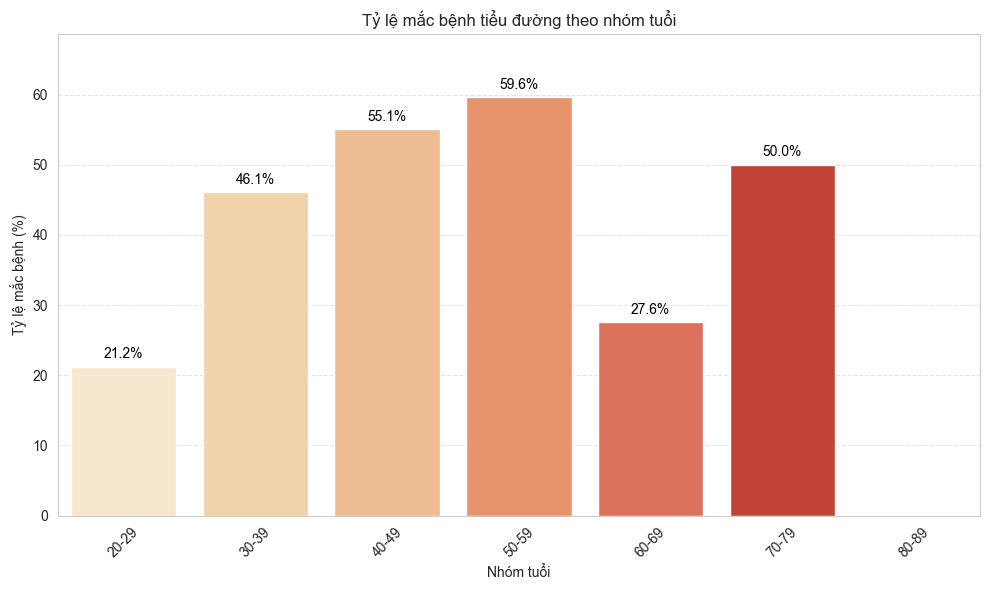

In [150]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Tỷ lệ mắc bệnh theo nhóm tuổi
age_disease_rate = (
    df.groupby('Age_Group')['Outcome']
      .mean()
      .reset_index(name='Diabetes_Rate')
)
age_disease_rate['Diabetes_Rate'] *= 100

# (Tùy chọn) chỉ lấy nhóm có dữ liệu
age_disease_rate = age_disease_rate.dropna()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Diabetes_Rate',
    palette='OrRd'
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 4),
                    textcoords='offset points')

ax.set_title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Tỷ lệ mắc bệnh (%)')
ax.set_ylim(0, age_disease_rate['Diabetes_Rate'].max() * 1.15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [151]:
scaler = StandardScaler()
X = df[["Glucose", "BMI"]]   # chỉ dùng 2 thuộc tính để vẽ

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

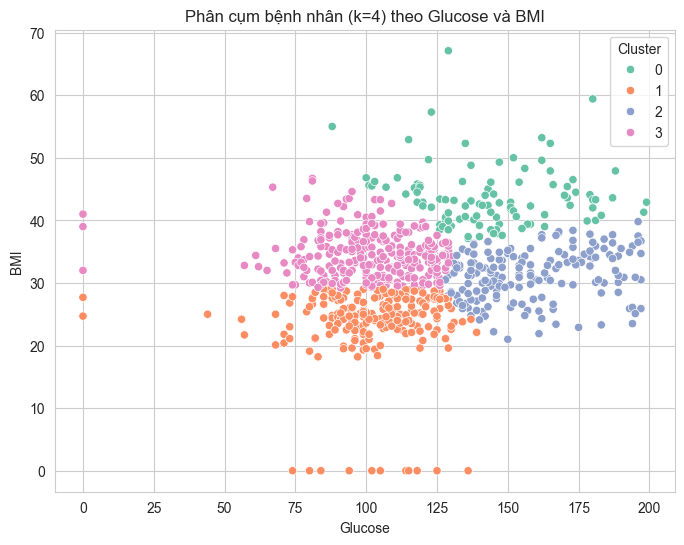

In [152]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Cluster",
    palette="Set2"
)

plt.title("Phân cụm bệnh nhân (k=4) theo Glucose và BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

In [153]:
# ================================
# THỐNG KÊ TỪNG CỤM
# ================================

for cluster in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster]
    
    count = len(cluster_data)
    percent = count / len(df) * 100
    
    age_mean = cluster_data["Age"].mean()
    age_std = cluster_data["Age"].std()
    
    bmi_mean = cluster_data["BMI"].mean()
    bmi_std = cluster_data["BMI"].std()
    
    glucose_mean = cluster_data["Glucose"].mean()
    glucose_std = cluster_data["Glucose"].std()
    
    # tỷ lệ mắc bệnh (Outcome = 1)
    disease_rate = cluster_data["Outcome"].mean() * 100

    print(f"\nCỤM {cluster} ({count} bệnh nhân - {percent:.1f}%):")
    print(f" - Tuổi trung bình: {age_mean:.1f} ± {age_std:.1f}")
    print(f" - BMI trung bình: {bmi_mean:.1f} ± {bmi_std:.1f}")
    print(f" - Glucose trung bình: {glucose_mean:.1f} ± {glucose_std:.1f}")
    print(f" - Tỷ lệ mắc bệnh: {disease_rate:.1f}%")


CỤM 0 (104 bệnh nhân - 13.5%):
 - Tuổi trung bình: 33.4 ± 10.0
 - BMI trung bình: 43.6 ± 5.0
 - Glucose trung bình: 144.0 ± 23.0
 - Tỷ lệ mắc bệnh: 64.4%

CỤM 1 (213 bệnh nhân - 27.7%):
 - Tuổi trung bình: 30.2 ± 11.7
 - BMI trung bình: 23.6 ± 6.2
 - Glucose trung bình: 102.2 ± 19.3
 - Tỷ lệ mắc bệnh: 10.8%

CỤM 2 (179 bệnh nhân - 23.3%):
 - Tuổi trung bình: 38.9 ± 13.6
 - BMI trung bình: 31.2 ± 3.9
 - Glucose trung bình: 158.3 ± 20.1
 - Tỷ lệ mắc bệnh: 61.5%

CỤM 3 (272 bệnh nhân - 35.4%):
 - Tuổi trung bình: 31.8 ± 9.7
 - BMI trung bình: 34.6 ± 3.6
 - Glucose trung bình: 102.0 ± 19.3
 - Tỷ lệ mắc bệnh: 25.0%


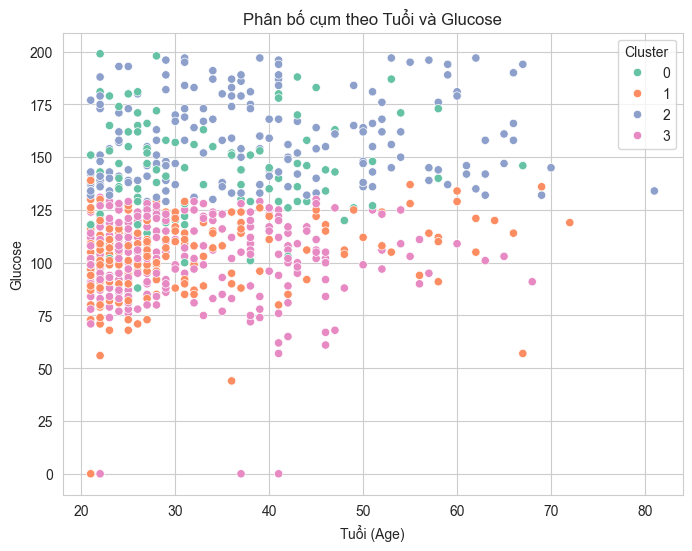

In [154]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Cluster",
    palette="Set2"
)

plt.title("Phân bố cụm theo Tuổi và Glucose")
plt.xlabel("Tuổi (Age)")
plt.ylabel("Glucose")

plt.show()

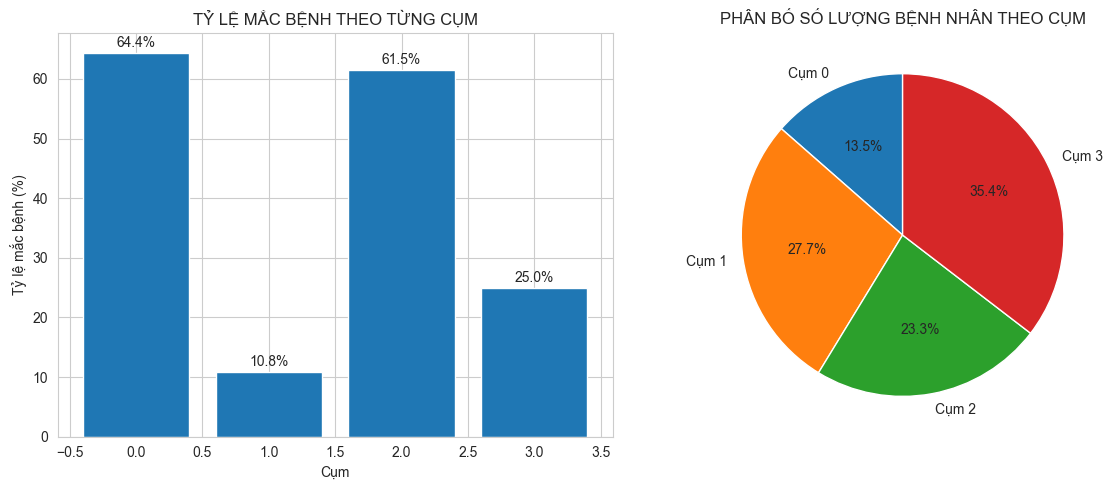

In [155]:
cluster_stats = df.groupby("Cluster").agg({
    "Outcome": "mean",   # tỷ lệ bệnh
    "Age": "count"       # số lượng
}).rename(columns={"Age": "Count"})

# chuyển sang %
cluster_stats["DiseaseRate"] = cluster_stats["Outcome"] * 100

# ================================
# VẼ BIỂU ĐỒ
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --------- BIỂU ĐỒ CỘT ---------
axes[0].bar(cluster_stats.index, cluster_stats["DiseaseRate"])

axes[0].set_title("TỶ LỆ MẮC BỆNH THEO TỪNG CỤM")
axes[0].set_xlabel("Cụm")
axes[0].set_ylabel("Tỷ lệ mắc bệnh (%)")

# hiển thị số trên cột
for i, v in enumerate(cluster_stats["DiseaseRate"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center')

# --------- PIE CHART ---------
axes[1].pie(
    cluster_stats["Count"],
    labels=[f"Cụm {i}" for i in cluster_stats.index],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("PHÂN BỐ SỐ LƯỢNG BỆNH NHÂN THEO CỤM")

plt.tight_layout()
plt.show()

In [156]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Age_Group',
       'Cluster'],
      dtype='object')


In [157]:
import statsmodels.api as sm

# ====== DATA CỦA BẠN ======
df = pd.read_csv("iris_eda-data/pima-indians-diabetes.data.csv",names=columns)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Logistic Regression
X = sm.add_constant(X)
model = sm.Logit(y, X).fit(disp=0)

params = model.params
conf = model.conf_int()

# ====== TẠO BẢNG ======
or_df = pd.DataFrame({
    "Yếu tố nguy cơ": params.index,
    "OR": np.exp(params),
    "CI thấp": np.exp(conf[0]),
    "CI cao": np.exp(conf[1]),
    "P-value": model.pvalues
})

# bỏ const
or_df = or_df.drop("const")

# ====== PHÂN LOẠI NGUY CƠ ======
def classify_or(or_val, p):
    if p >= 0.05:
        return "Không ý nghĩa"
    elif or_val >= 3:
        return "Nguy cơ rất cao"
    elif or_val >= 2:
        return "Nguy cơ cao"
    elif or_val >= 1:
        return "Nguy cơ trung bình"
    else:
        return "Bảo vệ"

or_df["Phân loại"] = or_df.apply(lambda row: classify_or(row["OR"], row["P-value"]), axis=1)

# ====== THÊM NGƯỠNG (giống bài bạn) ======
thresholds = {
    "Glucose": 126,
    "BMI": 35,
    "Age": 45,
    "Pregnancies": 4,
    "DiabetesPedigreeFunction": 0.5,
    "BloodPressure": 90,
    "Insulin": 166,
    "SkinThickness": 30
}

or_df["Ngưỡng"] = or_df["Yếu tố nguy cơ"].map(thresholds)

# ====== SẮP XẾP CHO ĐẸP ======
or_df = or_df[[
    "Yếu tố nguy cơ",
    "Ngưỡng",
    "OR",
    "CI thấp",
    "CI cao",
    "P-value",
    "Phân loại"
]]

# làm tròn giống báo cáo
or_df = or_df.round({
    "OR": 2,
    "CI thấp": 2,
    "CI cao": 2,
    "P-value": 4
})

print("\n=== BẢNG ODDS RATIO HOÀN CHỈNH ===")
print(or_df)


=== BẢNG ODDS RATIO HOÀN CHỈNH ===
                                    Yếu tố nguy cơ  Ngưỡng    OR  CI thấp  \
Pregnancies                            Pregnancies     4.0  1.13     1.06   
Glucose                                    Glucose   126.0  1.04     1.03   
BloodPressure                        BloodPressure    90.0  0.99     0.98   
SkinThickness                        SkinThickness    30.0  1.00     0.99   
Insulin                                    Insulin   166.0  1.00     1.00   
BMI                                            BMI    35.0  1.09     1.06   
DiabetesPedigreeFunction  DiabetesPedigreeFunction     0.5  2.57     1.43   
Age                                            Age    45.0  1.01     1.00   

                          CI cao  P-value           Phân loại  
Pregnancies                 1.20   0.0001  Nguy cơ trung bình  
Glucose                     1.04   0.0000  Nguy cơ trung bình  
BloodPressure               1.00   0.0111              Bảo vệ  
SkinThickness 

In [158]:
# ====== 1. TẠO ĐIỂM NGUY CƠ ======
def calculate_score(row):
    score = 0
    
    if row["Glucose"] >= 126: score += 4
    if row["BMI"] >= 35: score += 2
    if row["Age"] >= 45: score += 2
    if row["Pregnancies"] >= 4: score += 2
    if row["DiabetesPedigreeFunction"] >= 0.5: score += 2
    if row["BloodPressure"] >= 90: score += 1
    if row["Insulin"] >= 166: score += 2
    if row["SkinThickness"] >= 30: score += 1

    return score

df["RiskScore"] = df.apply(calculate_score, axis=1)

# ====== 2. PHÂN LOẠI ======
def classify(score):
    if score <= 3:
        return "Nguy cơ thấp"
    elif score <= 6:
        return "Nguy cơ vừa"
    elif score <= 9:
        return "Nguy cơ cao"
    else:
        return "Nguy cơ rất cao"

df["RiskLevel"] = df["RiskScore"].apply(classify)

# ====== 3. TẠO BẢNG THANG ĐIỂM (GIỐNG HÌNH) ======
score_table = pd.DataFrame({
    "Yếu tố nguy cơ": [
        "Glucose ≥ 126",
        "BMI ≥ 35",
        "Age ≥ 45",
        "Pregnancies ≥ 4",
        "DiabetesPedigreeFunction ≥ 0.5",
        "BloodPressure ≥ 90",
        "Insulin ≥ 166",
        "SkinThickness ≥ 30"
    ],
    "Điểm": [4, 2, 2, 2, 2, 1, 2, 1]
})

print("\n=== BẢNG THANG ĐIỂM NGUY CƠ ===")
print(score_table.to_string(index=False))


=== BẢNG THANG ĐIỂM NGUY CƠ ===
                Yếu tố nguy cơ  Điểm
                 Glucose ≥ 126     4
                      BMI ≥ 35     2
                      Age ≥ 45     2
               Pregnancies ≥ 4     2
DiabetesPedigreeFunction ≥ 0.5     2
            BloodPressure ≥ 90     1
                 Insulin ≥ 166     2
            SkinThickness ≥ 30     1


In [159]:
# ====== 1. PHÂN LOẠI THEO ĐIỂM ======
def classify(score):
    if score <= 3:
        return "Nguy cơ thấp (0 - 3)"
    elif score <= 6:
        return "Nguy cơ vừa (4 - 6)"
    elif score <= 9:
        return "Nguy cơ cao (7 - 9)"
    else:
        return "Nguy cơ rất cao (≥ 10)"

df["RiskLevel"] = df["RiskScore"].apply(classify)

# ====== 2. TẠO BẢNG THỐNG KÊ ======
summary = df.groupby("RiskLevel").agg(
    Tỷ_Lệ_Mắc_Bệnh =("Outcome", "mean"),
    Số_Lượng_BệnhNhân=("Outcome", "count")
).reset_index()

# đổi sang %
summary["Tỷ_Lệ_Mắc_Bệnh"] = summary["Tỷ_Lệ_Mắc_Bệnh"] * 100

# ====== 3. SẮP XẾP THỨ TỰ ======
order = ["Nguy cơ thấp (0 - 3)","Nguy cơ vừa (4 - 6)","Nguy cơ cao (7 - 9)","Nguy cơ rất cao (≥ 10)"]
summary["RiskLevel"] = pd.Categorical(summary["RiskLevel"], categories=order, ordered=True)
summary = summary.sort_values("RiskLevel")

# làm tròn đẹp
summary["Tỷ_Lệ_Mắc_Bệnh"] = summary["Tỷ_Lệ_Mắc_Bệnh"].round(1)

print("\n=== BẢNG PHÂN LOẠI NGUY CƠ ===")
print(summary.to_string(index=False))


=== BẢNG PHÂN LOẠI NGUY CƠ ===
             RiskLevel  Tỷ_Lệ_Mắc_Bệnh  Số_Lượng_BệnhNhân
  Nguy cơ thấp (0 - 3)            12.8                312
   Nguy cơ vừa (4 - 6)            33.8                204
   Nguy cơ cao (7 - 9)            60.9                161
Nguy cơ rất cao (≥ 10)            67.0                 91


In [160]:
from sklearn.metrics import roc_curve, auc
# các biến cần phân tích
features = ["Glucose", "BMI", "Age", "RiskScore"]

roc_results = []

for col in features:
    scores = df[col]
    
    fpr, tpr, thresholds = roc_curve(y, scores)
    roc_auc = auc(fpr, tpr)
    
    # Youden Index (tìm ngưỡng tối ưu)
    J = tpr - fpr
    ix = np.argmax(J)
    
    best_threshold = thresholds[ix]
    sensitivity = tpr[ix]
    specificity = 1 - fpr[ix]
    
    roc_results.append([
        col,
        roc_auc,
        best_threshold,
        sensitivity,
        specificity
    ])

# ====== TẠO BẢNG ======
roc_table = pd.DataFrame(roc_results, columns=[
    "Biến",
    "AUC",
    "Ngưỡng tối ưu",
    "Độ nhạy",
    "Đặc hiệu"
])

# làm tròn đẹp
roc_table = roc_table.round({
    "AUC": 2,
    "Ngưỡng tối ưu": 2,
    "Độ nhạy": 2,
    "Độ đặc hiệu": 2
})

print("\n=== BẢNG ROC ===")
print(roc_table.to_string(index=False))


=== BẢNG ROC ===
     Biến  AUC  Ngưỡng tối ưu  Độ nhạy  Đặc hiệu
  Glucose 0.79          124.0     0.70     0.732
      BMI 0.69           29.9     0.82     0.488
      Age 0.69           29.0     0.74     0.592
RiskScore 0.77            6.0     0.68     0.728


In [161]:
    import pandas as pd
    import numpy as np


    # Cột glucose và kết quả (Outcome: 0/1)
    glucose = df["Glucose"]
    y_true = df["Outcome"]

    # Các ngưỡng cần xét
    thresholds = [100, 110, 120, 130, 140, 150, 160]

    # Hàm tính các chỉ số
    def compute_metrics(y_true, y_pred):
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
        ppv = TP / (TP + FP) if (TP + FP) != 0 else 0
        npv = TN / (TN + FN) if (TN + FN) != 0 else 0
        accuracy = (TP + TN) / len(y_true)

        return sensitivity, specificity, ppv, npv, accuracy


    # Tạo bảng kết quả
    results = []

    for t in thresholds:
        y_pred = (glucose >= t).astype(int)

        sens, spec, ppv, npv, acc = compute_metrics(y_true, y_pred)

        results.append([
            f">={t} mg/dL",
            round(sens * 100, 1),
            round(spec * 100, 1),
            round(ppv * 100, 1),
            round(npv * 100, 1),
            round(acc * 100, 1)
        ])

    # Xuất bảng
    columns = ["Ngưỡng", "Độ nhạy (%)", "Độ đặc hiệu (%)", "PPV (%)", "NPV (%)", "Độ chính xác (%)"]
    result_df = pd.DataFrame(results, columns=columns)

    print(result_df)

        Ngưỡng  Độ nhạy (%)  Độ đặc hiệu (%)  PPV (%)  NPV (%)  \
0  >=100 mg/dL         94.0             36.2     44.1     91.9   
1  >=110 mg/dL         83.6             54.0     49.3     86.0   
2  >=120 mg/dL         73.9             67.6     55.0     82.8   
3  >=130 mg/dL         60.4             80.8     62.8     79.2   
4  >=140 mg/dL         50.4             87.6     68.5     76.7   
5  >=150 mg/dL         39.6             92.6     74.1     74.1   
6  >=160 mg/dL         31.3             96.4     82.4     72.4   

   Độ chính xác (%)  
0              56.4  
1              64.3  
2              69.8  
3              73.7  
4              74.6  
5              74.1  
6              73.7  


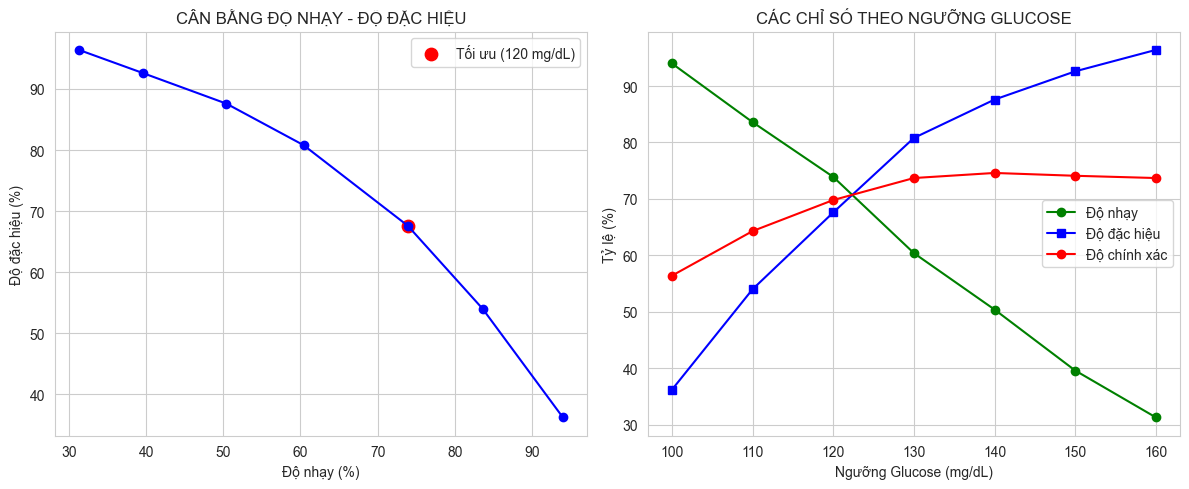

In [164]:
import matplotlib.pyplot as plt

# ====== LẤY DATA TỪ result_df ======
thresholds = result_df["Ngưỡng"].str.extract('(\d+)').astype(int)[0].values
sens = result_df["Độ nhạy (%)"].values
spec = result_df["Độ đặc hiệu (%)"].values
acc = result_df["Độ chính xác (%)"].values

# ====== TÌM ĐIỂM TỐI ƯU ======
opt_idx = (sens + spec).argmax()

# ====== VẼ ======
plt.figure(figsize=(12,5))

# ====== BIỂU ĐỒ 1: Sens vs Spec ======
plt.subplot(1,2,1)

plt.plot(sens, spec, marker='o', color='blue')
plt.scatter(sens[opt_idx], spec[opt_idx], color='red', s=80,
            label=f"Tối ưu ({thresholds[opt_idx]} mg/dL)")

plt.xlabel("Độ nhạy (%)")
plt.ylabel("Độ đặc hiệu (%)")
plt.title("CÂN BẰNG ĐỘ NHẠY - ĐỘ ĐẶC HIỆU")
plt.legend()
plt.grid(True)

# ====== BIỂU ĐỒ 2: Theo ngưỡng ======
plt.subplot(1,2,2)

plt.plot(thresholds, sens, marker='o', color='green', label="Độ nhạy")
plt.plot(thresholds, spec, marker='s', color='blue', label="Độ đặc hiệu")
plt.plot(thresholds, acc, marker='o', color='red', label="Độ chính xác")

plt.xlabel("Ngưỡng Glucose (mg/dL)")
plt.ylabel("Tỷ lệ (%)")
plt.title("CÁC CHỈ SỐ THEO NGƯỠNG GLUCOSE")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()